#DATA MINING AND NEURAL NETWORKS    
##Assignment 2.1 - Time-series Prediction

Prof. Dr. Ir. Johan A. K. Suykens     

In this file, we work on the time-series prediction using non-linear autoregressive model (NAR).

Specifically, we will conduct prediction on Climate Change dataset. The method is implemented with a ``python`` package named ``Skforecast``.


In [ ]:
# Please first load your google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Please go to the folder with all assignment files
# Please change the following path to your own path
!cd /content/drive/MyDrive/DMNN/DMNN2023

We implement the prediction method with a python package named ``Skforecast``, which is a simple library that contains the classes and functions necessary to adapt any ``scikit-learn`` regression model to forecasting problems.

We need to install the ``Skforecast`` with the following command.

In [2]:
!pip install skforecast

# Climate Change Forecast
In this section, we will conduct time-series prediction on the climate change dataset.

Please first download the data csv file from [here](https://drive.google.com/file/d/1q3D4h8XF6sqD1BgP9M9Yl0XPT9B7FvRy/view?usp=sharing), and put it into your working directory.

In [23]:
import numpy as np
import pandas as pd

# Load the global land temperature dataset
df = pd.read_csv("C:\\Users\\afs\\Documents\\7sem\\DataMining_NeuralNetworks\\exercise2.\\GlobalLandTemperaturesByCity.csv")

In [24]:
# List the cities included in the datasets
# You can choose any city that you like
df['City'].unique()

# Check if your chosen city is included in the data
print('Budapest' in df['City'].unique())

True


In [25]:
# Data Cleaning
df = df.dropna() # Remove null values
df_budapest = df[df.City == "Budapest"]
df_budapest.index = pd.to_datetime(df_budapest.dt)
df_budapest.head()
len(df_budapest) # Check the number of samples in the df_shanghai

3166

In [26]:
# Preserve only the average temperatures data
avg_tmp = df_budapest['AverageTemperature']
print(avg_tmp)

dt
1743-11-01     4.920
1744-04-01    12.224
1744-05-01    14.523
1744-06-01    17.735
1744-07-01    19.978
               ...  
2013-04-01    12.316
2013-05-01    16.866
2013-06-01    20.253
2013-07-01    22.546
2013-08-01    22.659
Name: AverageTemperature, Length: 3166, dtype: float64


## Visualize the dataset
Here we partition the dataset into training, validation and test sets. Note that test set is of 20% of the whole dataset, training is (80% $\times$ 80%) of the original dataset and validation is (80% $\times$ 20%) of the dataset.

In [27]:
# We choose the first 80% of the dataset as (training set + validation set)
# The rest of 20% as test set
import math

data_size = len(avg_tmp)
train_set = avg_tmp[:math.floor(data_size * 0.8*0.8)]
val_set = avg_tmp[math.floor(data_size * 0.8*0.8):math.floor(data_size * 0.8)]
test_set = avg_tmp[math.floor(data_size * 0.8):]

Text(0.5, 1.0, 'Average Temperature of Budapest from 1743 to 2013')

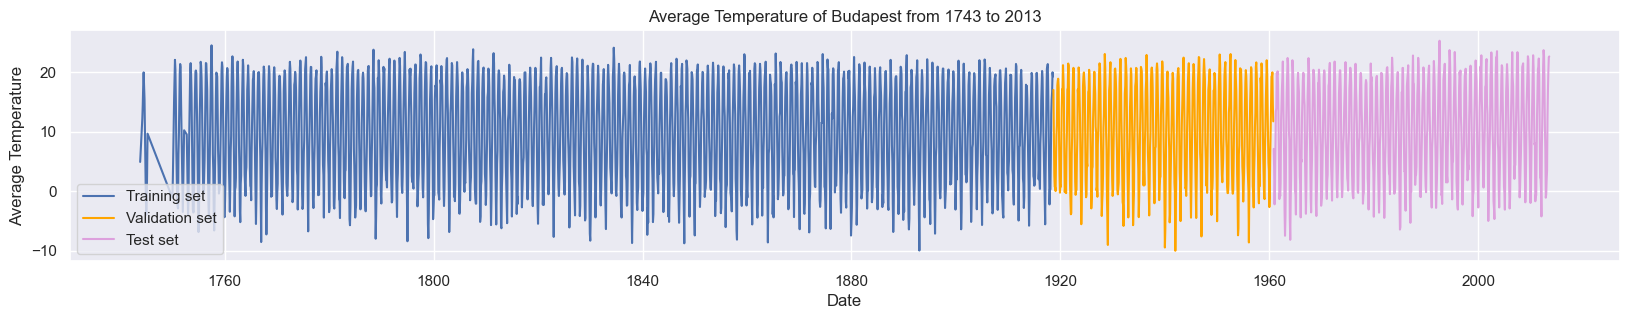

In [29]:
import matplotlib.pyplot as plt
# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

plt.rcParams["figure.dpi"]=100
plt.rcParams['savefig.dpi']=300

plt.figure(figsize=(20,3))
fig = plt.figure(1)
ax = fig.add_subplot(111) # 111: No. of rows, cols, index
ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature")
ax.plot(train_set, label="Training set")
ax.plot(val_set, label="Validation set", c="orange")
ax.plot(test_set, label="Test set", c="plum")
ax.legend()
plt.title("Average Temperature of Budapest from 1743 to 2013")
# plt.savefig("./global_temp_shanghai.jpg", bbox_inches='tight') # save figure

## Train Non-linear Autoregressive Model
Now, we start to train a non-linear autoregressive (NAR) model on the training set and choosing the hyper-parameters on the validation set.

If you choose support vector regressor as the regression model, then in addtion to tune on ``lags``, you need to tune on ``kernel``, ``gamma``, etc.
If you choose random forest, you mainly need to tune on ``lags``.
You can also choose other machine learning regression method for the autoregressive model.

After deciding the hyper-parameters, you can predict the results on the test set.

We will utilize package ``skforecast`` for implementation.

In [96]:
# Modeling and Forecasting
# First import the necessary sklearn regression method
from sklearn.neural_network import MLPRegressor # we use neural network as regressor
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR

# We import the prediction functions from skforecast
from skforecast.ForecasterAutoreg import ForecasterAutoreg

forecaster = ForecasterAutoreg(
    regressor = MLPRegressor(hidden_layer_sizes=(100,100), activation='logistic', batch_size=64, max_iter=1000), # you can tune the hidden dimension and other hyper-parameters here
    lags = 6 # you can tune the lags here
    )

# fit model on the training set
forecaster.fit(y=train_set)
# print the NAR model
forecaster

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


ForecasterAutoreg 
Regressor: MLPRegressor(activation='logistic', batch_size=64,
             hidden_layer_sizes=(100, 100), max_iter=1000) 
Lags: [1 2 3 4 5 6] 
Transformer for y: None 
Transformer for exog: None 
Window size: 6 
Weight function included: False 
Differentiation order: None 
Exogenous included: False 
Type of exogenous variable: None 
Exogenous variables names: None 
Training range: [0, 2025] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: {'activation': 'logistic', 'alpha': 0.0001, 'batch_size': 64, 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': None, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False} 
fit_kwargs: 

After fitting/training the model on the training set, we evaluate the results on the validation set.

In [97]:
steps = len(val_set)
predictions = forecaster.predict(steps=steps)
predictions.head(5)

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


6     14.612196
7      9.278151
8      3.789449
9     -0.666384
10    -2.821283
Name: pred, dtype: float64

In [98]:
# compute the root mean squared error between the predictions and validation set
mse = mean_squared_error(val_set, predictions)
print("The MSE on the validation set is: {:.3f}".format(mse))

The MSE on the validation set is: 4.264


We now visualize the prediction results and the ground-truth validation data.

Text(0.5, 1.0, 'Prediction results on validation of Shanghai dataset')

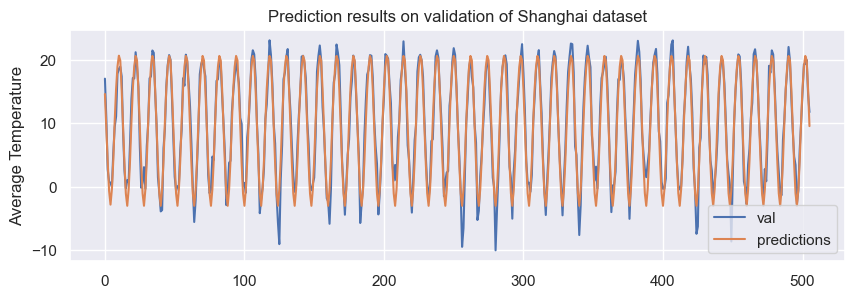

In [99]:
# Plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(val_set.to_numpy(), label='val')
ax.plot(predictions.to_numpy(), label='predictions')
ax.legend()
ax.set_ylabel("Average Temperature")
plt.title("Prediction results on validation of Shanghai dataset")

## Tune the hyper-parameter ``lags``
We first try a large range of lags as follows:

In [112]:
lag_list = np.arange(2,50,2)
mse_list = []
for i in range(len(lag_list)):
    # Set regressor
    forecaster = ForecasterAutoreg(
        regressor = MLPRegressor(hidden_layer_sizes=(100,100), activation='logistic', max_iter=1000), # you can tune the hidden dimension and other hyper-parameters here
        # regressor = SVR(kernel='rbf', gamma='scale', max_iter=1000),
        lags = int(lag_list[i]) # you can try different lags here
    )

    # Trainig on training set
    forecaster.fit(y=train_set)

    # Evaluate model on validation set
    steps = len(val_set)
    predictions = forecaster.predict(steps=steps)

    # Compute MSE between predictions and ground-truth data

    mse = mean_squared_error(val_set, predictions)
    mse_list.append(mse)
    print("The MSE on the validation set is: {:.3f}".format(mse))

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 14.082


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 5.432


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


...

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 7.390


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 6.416
The MSE on the validation set is: 5.723


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


matplotlib.legend WARNING No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([<matplotlib.axis.XTick at 0x1bbaa2b1990>,
 [Text(0, 0, '2'),
  Text(1, 0, '4'),
  Text(2, 0, '6'),
  Text(3, 0, '8'),
  Text(4, 0, '10'),
  Text(5, 0, '12'),
  Text(6, 0, '14'),
  Text(7, 0, '16'),
  Text(8, 0, '18'),
  Text(9, 0, '20'),
  Text(10, 0, '22'),
  Text(11, 0, '24'),
  Text(12, 0, '26'),
  Text(13, 0, '28'),
  Text(14, 0, '30'),
  Text(15, 0, '32'),
  Text(16, 0, '34'),
  Text(17, 0, '36'),
  Text(18, 0, '38'),
  Text(19, 0, '40'),
  Text(20, 0, '42'),
  Text(21, 0, '44'),
  Text(22, 0, '46'),
  Text(23, 0, '48')])

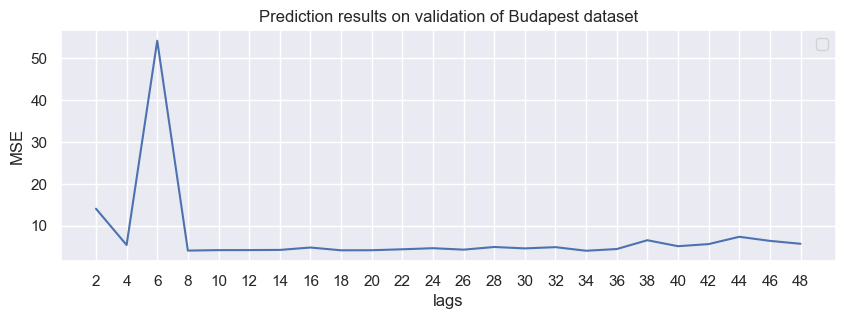

In [113]:
# Plot the MSE_list curve to select the best lags
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(mse_list)
ax.legend()
ax.set_xlabel("lags")
ax.set_ylabel("MSE")
plt.title("Prediction results on validation of Budapest dataset")
plt.xticks(np.arange(len(lag_list)),np.arange(2,50,2))

We now try a smaller range of lags that gives the lowest MSE.

In [118]:
# We change to a smaller range of lags
lag_list = np.arange(6,15,1)
mse_list = []
for i in range(len(lag_list)):
    # Set regressor
    forecaster = ForecasterAutoreg(
        regressor = MLPRegressor(hidden_layer_sizes=(100,100,100,100), activation='logistic', max_iter=1000),
        # regressor = SVR(kernel='rbf', gamma='scale', max_iter=1000),
        lags = int(lag_list[i]) # you can try different lags here
    )

    # Trainig on training set
    forecaster.fit(y=train_set)

    # Evaluate model on validation set
    steps = len(val_set)
    predictions = forecaster.predict(steps=steps)

    # Compute MSE between predictions and ground-truth data

    mse = mean_squared_error(val_set, predictions)
    mse_list.append(mse)
    print("The MSE on the validation set is: {:.3f}".format(mse))

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 117.289


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 4.152


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


...

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 4.311


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


The MSE on the validation set is: 4.120
The MSE on the validation set is: 4.185


c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


matplotlib.legend WARNING No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([<matplotlib.axis.XTick at 0x1bbaa41a890>,
 [Text(0, 0, '6'),
  Text(1, 0, '7'),
  Text(2, 0, '8'),
  Text(3, 0, '9'),
  Text(4, 0, '10'),
  Text(5, 0, '11'),
  Text(6, 0, '12'),
  Text(7, 0, '13'),
  Text(8, 0, '14')])

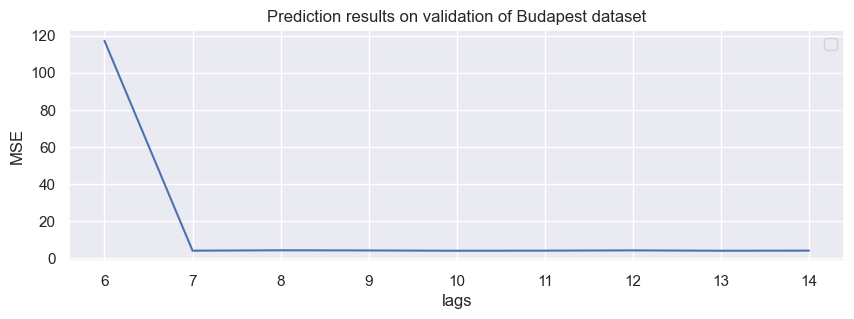

In [119]:
# Plot the MSE_list curve to select the best lags
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(mse_list)
ax.legend()
ax.set_xlabel("lags")
ax.set_ylabel("MSE")
plt.title("Prediction results on validation of Budapest dataset")
plt.xticks(np.arange(9),np.arange(6,15,1))

In [120]:
# Seems that lag=5 gives good prediction results
# Hence, we try lag=5
forecaster = ForecasterAutoreg(
        regressor = MLPRegressor(hidden_layer_sizes=(100,100), activation='logistic', max_iter=1000),
        # regressor = SVR(kernel='rbf', gamma='scale', max_iter=1000),
        lags = 13
    )

# Trainig on training set
forecaster.fit(y=train_set)

c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:805: UserWarning: `y` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


In [121]:
# Evaluate model on test set
steps = len(val_set) + len(test_set)
predictions = forecaster.predict(steps=steps)[len(val_set):]

# Compute MSE between predictions and ground-truth data
mse = mean_squared_error(test_set, predictions)
print("The MSE of prediction results on the test set is: {:.3f}\n".format(mse))

The MSE of prediction results on the test set is: 4.231



c:\Users\afs\anaconda3\Lib\site-packages\skforecast\utils\utils.py:867: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


Text(0.5, 1.0, 'Prediction results on test set of Budapest dataset (lag=9)')

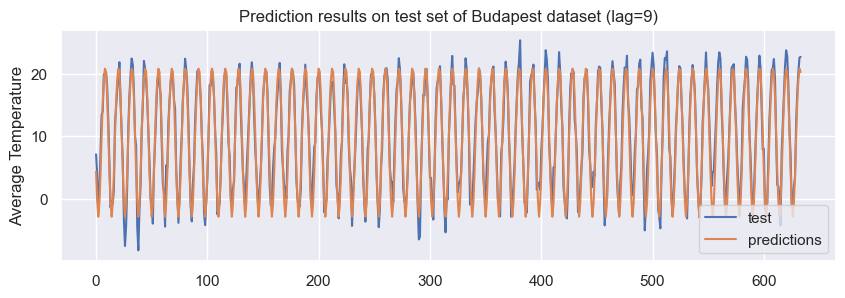

In [109]:
# Plot the prediction results on the test set
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(test_set.to_numpy(), label='test')
ax.plot(predictions.to_numpy(), label='predictions')
ax.legend()
ax.set_ylabel("Average Temperature")
plt.title("Prediction results on test set of Budapest dataset (lag=9)")